In [1]:
import numpy as np
import pandas as pd
from tensorflow import keras
from keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

data = pd.read_csv('tic_tac_toe.data', header=None)

In [2]:
#Separating inputs and target data
X = data.iloc[:, :9]
y = data.iloc[:, -1] 

#Converting positions to numbers
X = X.replace({'x': 1, 'o': -1, 'b': 0}).astype('float32')

#Converting targets to numbers
y = y.replace({'positive': 1, 'negative': 0}).astype('float32')

# Spliting into training and test
x_train, x_test, y_train, y_test = train_test_split(X.values, y.values, test_size=0.2, random_state=42)

#Constructing the nn
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(9,)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

#Compiling the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#Training the model
history = model.fit(x_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

#Running it on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

Epoch 1/50


C:\Users\sydne\AppData\Local\Temp\ipykernel_69612\1464692711.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace({'x': 1, 'o': -1, 'b': 0}).astype('float32')
C:\Users\sydne\AppData\Local\Temp\ipykernel_69612\1464692711.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'positive': 1, 'negative': 0}).astype('float32')
c:\Users\sydne\OneDrive\Documents\DAL - Masters\Fall 2025\Machine Learning 6505\Assignments\keras_pytorch_assignment_4\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarni

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5948 - loss: 0.6560 - val_accuracy: 0.6948 - val_loss: 0.5951
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6667 - loss: 0.6301 - val_accuracy: 0.7273 - val_loss: 0.5713
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7108 - loss: 0.5929 - val_accuracy: 0.7532 - val_loss: 0.5550
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6993 - loss: 0.5702 - val_accuracy: 0.7727 - val_loss: 0.5407
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6944 - loss: 0.5704 - val_accuracy: 0.7662 - val_loss: 0.5280
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7141 - loss: 0.5405 - val_accuracy: 0.7792 - val_loss: 0.5176
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7500 - loss: 0.5401 - val_accuracy: 0.7727 - val_loss: 0.5096
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7402 - loss: 0.5291 - val_accuracy: 0.7727 - val_loss: 0.5014
Ep

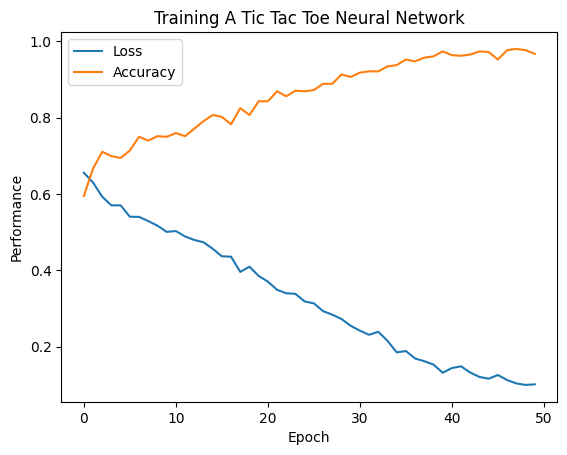

In [3]:
#Plotting on Matplotlib
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Training A Tic Tac Toe Neural Network')
plt.xlabel('Epoch')
plt.ylabel('Performance')
plt.legend()
plt.show()